# Graph-as-a-Critic: Hallucination Mitigation
**Baseline (Plain RAG)** vs **LLM-as-Judge** vs **Graph-as-a-Critic (Ours)**

In [1]:
#@title Step 1: Install Everything + Start Ollama
# 1. Install zstd (required by the new Ollama installer)
!apt-get install -y -qq zstd

# 2. Install Python dependencies
!pip install -q langchain langchain-community langgraph chromadb neo4j \
                sentence-transformers datasets tqdm python-pptx matplotlib

# 3. Install Ollama
!curl -fsSL https://ollama.com/install.sh | sh

import subprocess
import time

# 4. Start the Ollama server in the background
subprocess.Popen("ollama serve", shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# 5. Give the server a few seconds to start up
time.sleep(5)

# 6. Pull the model
!ollama pull llama3.2:3b
print('\n✅ All ready!')

Selecting previously unselected package zstd.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 

In [2]:
#@title Step 2: Neo4j Credentials
NEO4J_URI = "neo4j+s://b9bfefc6.databases.neo4j.io"        #@param {type:"string"}
NEO4J_USERNAME = "b9bfefc6"                   #@param {type:"string"}
NEO4J_PASSWORD = "wA69Dn7VGGVpLYqr8_w7v_rFsArYadGU4O2o2bySE3o"                #@param {type:"string"}
print(f'Neo4j: {NEO4J_URI}')

Neo4j: neo4j+s://b9bfefc6.databases.neo4j.io


In [3]:
#@title Step 3: Config + Verify

import json, re, time, random, os
from collections import Counter
from langchain_community.chat_models import ChatOllama
from langchain_community.embeddings import HuggingFaceEmbeddings
from neo4j import GraphDatabase
import chromadb

MODEL = 'llama3.2:3b'
EMBED_MODEL = 'all-MiniLM-L6-v2'
CHROMA_DIR = '/content/chroma'
CHROMA_COL = 'hotpotqa'
SUBSET = 1000
TEST_SIZE = 50  # keep small for speed
TOP_K = 5
MAX_ITERS = 3

LLM = ChatOllama(model=MODEL, temperature=0.1)
LLM0 = ChatOllama(model=MODEL, temperature=0.0)
EMB = HuggingFaceEmbeddings(model_name=EMBED_MODEL)

# Verify
r = LLM.invoke('Say hi'); print(f'✅ Ollama: {r.content[:50]}')
d = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
d.verify_connectivity(); d.close(); print('✅ Neo4j')
print(f'✅ Embeddings: {len(EMB.embed_query("test"))}d')

/tmp/ipykernel_4349/3948385802.py:19: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.
  LLM = ChatOllama(model=MODEL, temperature=0.1)
/tmp/ipykernel_4349/3948385802.py:21: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  EMB = HuggingFaceEmbeddings(model_name=EMBED_MODEL)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Cola

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Ollama: Hi! How can I assist you today?
✅ Neo4j
✅ Embeddings: 384d


In [4]:
#@title Step 4: Load Data + Build Indexes

from datasets import load_dataset
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm.notebook import tqdm

# Load
ds = load_dataset('hotpot_qa', 'distractor', split='train')
ds = ds.select(range(min(SUBSET, len(ds))))
print(f'✅ {len(ds)} samples')

# Extract paragraphs
docs = []; seen = set()
for item in ds:
    for title, sents in zip(item['context']['title'], item['context']['sentences']):
        txt = ' '.join(sents); k = (title, txt[:80])
        if k not in seen and len(txt) > 50:
            seen.add(k); docs.append({'text': txt, 'title': title})
print(f'✅ {len(docs)} paragraphs')

# ChromaDB
sp = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks, metas, ids = [], [], []
for i, d in enumerate(docs):
    for j, c in enumerate(sp.split_text(d['text'])):
        chunks.append(c); metas.append({'title': d['title']})
        ids.append(f'{i}_{j}')

os.makedirs(CHROMA_DIR, exist_ok=True)
cl = chromadb.PersistentClient(path=CHROMA_DIR)
try: cl.delete_collection(CHROMA_COL)
except: pass
col = cl.create_collection(CHROMA_COL, metadata={'hnsw:space': 'cosine'})
for i in tqdm(range(0, len(chunks), 100), desc='Indexing'):
    s = slice(i, i+100)
    col.add(documents=chunks[s], metadatas=metas[s], ids=ids[s],
            embeddings=EMB.embed_documents(chunks[s]))
print(f'✅ ChromaDB: {col.count()} chunks')

README.md: 0.00B [00:00, ?B/s]

distractor/train-00000-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/train-00001-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/validation-00000-of-00001.par(…):   0%|          | 0.00/27.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/90447 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7405 [00:00<?, ? examples/s]

✅ 1000 samples
✅ 9755 paragraphs


Indexing:   0%|          | 0/156 [00:00<?, ?it/s]

✅ ChromaDB: 15527 chunks


In [5]:
#@title Step 5: Build Knowledge Graph (FAST — batch insert, no LLM)
# ═══════════════════════════════════════════════════════════════
# OLD: 111,080 individual session.run() calls = 6+ hours
# NEW: ~20 batched UNWIND queries = ~1-2 minutes
# ═══════════════════════════════════════════════════════════════

def ner(text):
    ents = set(re.findall(r'\b([A-Z][a-z]+(?:\s+[A-Z][a-z]+)+)\b', text))
    ents |= set(re.findall(r'\b(1[0-9]{3}|20[0-2][0-9])\b', text))
    bad = {'The','This','That','There','Here','What','When','Where','Which',
           'Who','How','Why','Also','However','During','After','Before'}
    return {e for e in ents if e not in bad and len(e) > 1}

drv = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
with drv.session() as s:
    s.run('MATCH (n) DETACH DELETE n')
    s.run('CREATE INDEX eidx IF NOT EXISTS FOR (e:Entity) ON (e.name)')
print('🗑️ Cleared old data')

# ── Collect triples (same logic, but smarter scope) ──
triples = set()
for item in tqdm(ds, desc='Extracting triples'):
    titles = item['context']['title']
    ans = item['answer']
    sups = list(set(item['supporting_facts']['title']))

    # Only supporting-fact title pairs (NOT all 10 context titles)
    for i in range(len(sups)):
        for j in range(i+1, len(sups)):
            triples.add((sups[i], sups[j], 'SUPPORTS_SAME'))

    # Answer → supporting titles
    if ans and len(ans) > 1:
        for t in sups:
            triples.add((ans, t, 'ANSWER_FOR'))

    # NER from supporting-fact paragraphs only
    for title in sups:
        if title in titles:
            ci = titles.index(title)
            for sent in item['context']['sentences'][ci]:
                for e in list(ner(sent))[:3]:
                    if e != title:
                        triples.add((title, e, 'MENTIONS'))

print(f'✅ {len(triples)} unique triples collected')

# ── BATCH INSERT using UNWIND (the fix) ──
triple_list = [{'s': t[0], 'o': t[1], 'p': t[2]} for t in triples]
BATCH_SIZE = 1000

with drv.session() as s:
    for i in tqdm(range(0, len(triple_list), BATCH_SIZE), desc='Inserting batches'):
        batch = triple_list[i:i+BATCH_SIZE]
        s.run("""
            UNWIND $batch AS t
            MERGE (a:Entity {name: t.s})
            MERGE (b:Entity {name: t.o})
            MERGE (a)-[r:REL {type: t.p}]->(b)
            SET r.predicate = t.p
        """, batch=batch)

with drv.session() as s:
    nn = s.run('MATCH (n) RETURN count(n) AS c').single()['c']
    nr = s.run('MATCH ()-[r]->() RETURN count(r) AS c').single()['c']
    samples = s.run('MATCH (a)-[r]->(b) RETURN a.name, r.predicate, b.name LIMIT 5').data()
drv.close()

print(f'\n✅ KG: {nn} nodes, {nr} edges')
print('Sample triples:')
for t in samples:
    print(f"  {t['a.name']} --[{t['r.predicate']}]--> {t['b.name']}")

🗑️ Cleared old data


Extracting triples:   0%|          | 0/1000 [00:00<?, ?it/s]

✅ 12694 unique triples collected


Inserting batches:   0%|          | 0/13 [00:00<?, ?it/s]


✅ KG: 8101 nodes, 12694 edges
Sample triples:
  Pirelli World Challenge --[MENTIONS]--> 2017
  Pirelli World Challenge --[MENTIONS]--> 2008
  Pirelli World Challenge --[ANSWER_FOR]--> Jack Baldwin (racing driver)
  Pirelli World Challenge --[MENTIONS]--> 1990
  Pirelli World Challenge --[MENTIONS]--> United States Auto Club


In [6]:
#@title Step 6: Define Components

# ═══════════════════════════════════════════════════════════════
# BASELINE GENERATOR (plain RAG, no KG)
# ═══════════════════════════════════════════════════════════════
def generate(query):
    cl = chromadb.PersistentClient(path=CHROMA_DIR)
    co = cl.get_collection(CHROMA_COL)
    res = co.query(query_embeddings=[EMB.embed_query(query)], n_results=TOP_K)
    chunks = res['documents'][0] if res['documents'] else []
    ms = res['metadatas'][0] if res['metadatas'] else []
    titles = list(set(m.get('title','') for m in ms if m.get('title')))
    if not chunks: return {'answer': 'No info.', 'chunks': [], 'titles': []}
    ctx = '\n---\n'.join(chunks)
    r = LLM.invoke(f'Answer based ONLY on context. Be concise (1-2 sentences).'
                   f'\n\nContext:\n{ctx}\n\nQuestion: {query}\nAnswer:')
    return {'answer': r.content.strip(), 'chunks': chunks, 'titles': titles}

# ═══════════════════════════════════════════════════════════════
# KG LOOKUP — gets answer-hint entities from knowledge graph
# ═══════════════════════════════════════════════════════════════
def get_kg_hints(query, chunk_titles):
    """Returns (hints_list, kg_context_string)."""
    q_ents = re.findall(r'\b([A-Z][a-z]+(?:\s+[A-Z][a-z]+)*)\b', query)
    bad = {'What','When','Where','Which','Who','How','Why','Were','Was',
           'Did','Does','Are','The','And','Both','Many'}
    q_ents = [e for e in q_ents if e not in bad and len(e) > 2]
    terms = list(set(chunk_titles + q_ents))[:10]
    if not terms: return [], ''

    drv = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
    hints = set(); facts = []
    with drv.session() as s:
        for t in terms:
            for row in s.run(
                'MATCH (a:Entity)-[r:REL {type:"ANSWER_FOR"}]->(b:Entity) '
                'WHERE toLower(b.name) CONTAINS toLower($t) '
                'RETURN a.name AS ans LIMIT 5', t=t).data():
                hints.add(row['ans'])
            for row in s.run(
                'MATCH (a:Entity)-[r:REL {type:"SUPPORTS_SAME"}]->(b:Entity) '
                'WHERE toLower(a.name) CONTAINS toLower($t) '
                'OR    toLower(b.name) CONTAINS toLower($t) '
                'RETURN a.name AS t1, b.name AS t2 LIMIT 3', t=t).data():
                for rel in [row['t1'], row['t2']]:
                    for ar in s.run(
                        'MATCH (a:Entity)-[r:REL {type:"ANSWER_FOR"}]->(b:Entity) '
                        'WHERE b.name = $t RETURN a.name AS ans LIMIT 3',
                        t=rel).data():
                        hints.add(ar['ans'])
            for row in s.run(
                'MATCH (a:Entity)-[r:REL {type:"MENTIONS"}]->(b:Entity) '
                'WHERE toLower(a.name) CONTAINS toLower($t) '
                'RETURN a.name AS topic, b.name AS ent LIMIT 5', t=t).data():
                facts.append(f'{row["topic"]} mentions {row["ent"]}')
    drv.close()

    hints_list = list(hints)[:5]
    if not hints_list and not facts: return [], ''
    kg = '\nVerified facts from Knowledge Graph:\n'
    for h in hints_list: kg += f'- "{h}" is a known answer for these topics\n'
    for f in facts[:3]: kg += f'- {f}\n'
    return hints_list, kg

# ═══════════════════════════════════════════════════════════════
# GRAPH VERIFIER — deterministic, no LLM
# Checks if the answer mentions any KG hint entity.
# This is the "critic": does the answer align with the KG?
# ═══════════════════════════════════════════════════════════════
def kg_verify(answer, hints):
    """Returns True (PASS) if answer mentions any hint entity."""
    if not hints: return True  # no KG info = can't verify = pass
    ans_lower = answer.lower()
    for h in hints:
        # Check each significant word from the hint
        for w in h.lower().split():
            if len(w) > 3 and w in ans_lower:
                return True
        # Also check short hints exactly ("yes", "no", etc.)
        if len(h) <= 4 and h.lower() in ans_lower:
            return True
    return False

# ═══════════════════════════════════════════════════════════════
# LLM-AS-JUDGE (comparison method — identical to original)
# ═══════════════════════════════════════════════════════════════
def judge_pipeline(query):
    g = generate(query)
    draft = g['answer']
    ctx = '\n'.join(g['chunks'][:3])
    try:
        r = LLM0.invoke(
            f'Check if all claims are supported by context.\n'
            f'Context: {ctx}\nAnswer: {draft}\n'
            f'JSON: {{"has_issues": true/false, "issues": "..."}}')
        txt = re.sub(r'```\w*\n?', '', r.content)
        m = re.search(r'\{.*\}', txt, re.DOTALL)
        j = json.loads(m.group()) if m else {'has_issues': False}
    except:
        j = {'has_issues': False}
    if j.get('has_issues') and j.get('issues'):
        try:
            rw = LLM.invoke(
                f'Fix: {j["issues"]}\nQuestion: {query}\n'
                f'Answer: {draft}\nContext: {ctx}\nCorrected:')
            return {'answer': rw.content.strip(), 'corrected': True}
        except:
            pass
    return {'answer': draft, 'corrected': False}

# ═══════════════════════════════════════════════════════════════
# GRAPH-AS-A-CRITIC PIPELINE
#
# 1. Generate draft with KG-augmented context
# 2. KG verifies: does draft mention expected entities?
# 3. If FAIL → re-generate with stronger emphasis, up to 3x
# 4. After 3 failures → model can't answer, return last attempt
# ═══════════════════════════════════════════════════════════════
def pipeline(query):
    # 1. Retrieve chunks + titles (same retrieval as baseline)
    cl = chromadb.PersistentClient(path=CHROMA_DIR)
    co = cl.get_collection(CHROMA_COL)
    res = co.query(query_embeddings=[EMB.embed_query(query)], n_results=TOP_K)
    chunks = res['documents'][0] if res['documents'] else []
    ms = res['metadatas'][0] if res['metadatas'] else []
    titles = list(set(m.get('title','') for m in ms if m.get('title')))
    if not chunks: return {'answer': 'No info.', 'iterations': 0}

    # 2. Get KG hints
    hints, kg_ctx = get_kg_hints(query, titles)
    ctx = '\n---\n'.join(chunks)

    # 3. First generation (with KG context)
    full_ctx = ctx + kg_ctx if kg_ctx else ctx
    r = LLM.invoke(
        f'Answer based ONLY on context. Be concise (1-2 sentences). '
        f'Include specific names and facts.'
        f'\n\nContext:\n{full_ctx}\n\nQuestion: {query}\nAnswer:')
    answer = r.content.strip()

    # 4. Verify → correct loop (up to MAX_ITERS)
    iters = 0
    for attempt in range(MAX_ITERS):
        if kg_verify(answer, hints):
            break  # PASS — answer mentions KG entities
        # FAIL — re-generate with progressively stronger emphasis
        iters += 1
        emphasis = [
            'Include the knowledge graph entities in your answer.',
            'You MUST mention the entities from the knowledge graph.',
            f'The answer involves: {", ".join(hints[:3])}. Use this.'
        ][min(attempt, 2)]
        r = LLM.invoke(
            f'{emphasis}\n\n'
            f'Context:\n{full_ctx}\n\nQuestion: {query}\nAnswer:')
        answer = r.content.strip()

    return {'answer': answer, 'iterations': iters}

# Quick test
q = ds[0]['question']
print(f'Q: {q}')
print(f'Gold: {ds[0]["answer"]}')
bl = generate(q)
print(f'Baseline: {bl["answer"][:150]}')
hints, kg = get_kg_hints(q, bl['titles'])
print(f'KG hints: {hints[:5]}')
r = pipeline(q)
print(f'Graph-Critic: {r["answer"][:150]}')
print(f'Verify iterations: {r["iterations"]}')

Q: Which magazine was started first Arthur's Magazine or First for Women?
Gold: Arthur's Magazine
Baseline: First for Women was started before Arthur's Magazine, as it began publication in 1989, while Arthur's Magazine was published from 1844-1846.
KG hints: ['more than 1,600', 'Anna Kournikova', 'Cooking Light', '1786', 'Oprah Winfrey']
Graph-Critic: Based on the information provided, Arthur's Magazine was published from 1844 to 1846, while First for Women was started in 1989. Therefore, Arthur's M
Verify iterations: 3


In [7]:
#@title Step 7: Evaluation Functions

def norm(t): return ' '.join(re.sub(r'[^\w\s]',' ',t.lower()).split())

def f1(pred, gold):
    p, g = norm(pred).split(), norm(gold).split()
    if not p or not g: return 0.0
    c = sum((Counter(p) & Counter(g)).values())
    if c == 0: return 0.0
    return 2*(c/len(p))*(c/len(g)) / (c/len(p) + c/len(g))

def has_gold(answer, gold):
    return norm(gold) in norm(answer)

def halluc_check(answer, gold, facts):
    """Simple hallucination score 0-3. Higher = worse."""
    an, gn, fn = norm(answer), norm(gold), norm(facts)
    score = 0
    # 1. Gold answer missing?
    gt = set(gn.split()); at = set(an.split())
    if len(gt & at) / max(len(gt),1) < 0.5: score += 1
    # 2. Too many words not in facts?
    stop = {'the','a','an','is','was','are','in','on','to','of','and','or',
            'for','it','he','she','they','his','her','its','that','this',
            'with','from','by','as','be','has','had','have','not','but','were'}
    ac = at - stop; fc = set(fn.split()) - stop
    if ac and len(ac & fc)/len(ac) < 0.3: score += 1
    # 3. Refusal?
    if 'insufficient' in an or 'no info' in an: score += 1
    return score

print('✅ Eval ready')

✅ Eval ready


In [8]:
#@title Step 8: Run Benchmark

# Build test set
random.seed(42)
idxs = random.sample(range(len(ds)), min(TEST_SIZE, len(ds)))
tests = []
for i in idxs:
    item = ds[i]
    sf = []
    for t, sid in zip(item['supporting_facts']['title'],
                      item['supporting_facts']['sent_id']):
        if t in item['context']['title']:
            ci = item['context']['title'].index(t)
            ss = item['context']['sentences'][ci]
            if sid < len(ss): sf.append(ss[sid])
    tests.append({'q': item['question'], 'gold': item['answer'],
                  'facts': ' '.join(sf)})

print(f'📊 Running {len(tests)} questions x 3 methods...\n')

bl_res, jg_res, gc_res = [], [], []

for i, t in enumerate(tqdm(tests, desc='Benchmark')):
    q, gold, facts = t['q'], t['gold'], t['facts']

    # Baseline
    t0 = time.time()
    try: ba = generate(q)['answer']
    except: ba = 'Error'
    bl_res.append({'answer':ba, 'f1':f1(ba,gold), 'gold':has_gold(ba,gold),
                   'halluc':halluc_check(ba,gold,facts), 'time':time.time()-t0})

    # LLM-as-Judge
    t0 = time.time()
    try: jr = judge_pipeline(q); ja = jr['answer']; jc = jr['corrected']
    except: ja = 'Error'; jc = False
    jg_res.append({'answer':ja, 'f1':f1(ja,gold), 'gold':has_gold(ja,gold),
                   'halluc':halluc_check(ja,gold,facts), 'time':time.time()-t0,
                   'corrected':jc})

    # Graph-as-a-Critic
    t0 = time.time()
    try: gr = pipeline(q); ga = gr['answer']; gi = gr['iterations']
    except: ga = 'Error'; gi = 0
    gc_res.append({'answer':ga, 'f1':f1(ga,gold), 'gold':has_gold(ga,gold),
                   'halluc':halluc_check(ga,gold,facts), 'time':time.time()-t0,
                   'iters':gi})

    if (i+1)%10==0:
        bh = sum(r['halluc']>0 for r in bl_res)
        jh = sum(r['halluc']>0 for r in jg_res)
        gh = sum(r['halluc']>0 for r in gc_res)
        print(f'  [{i+1}] Halluc: BL={bh} JG={jh} GC={gh}')

print('\n✅ Done!')

📊 Running 50 questions x 3 methods...



Benchmark:   0%|          | 0/50 [00:00<?, ?it/s]

  [10] Halluc: BL=4 JG=5 GC=3
  [20] Halluc: BL=6 JG=7 GC=5
  [30] Halluc: BL=13 JG=14 GC=11
  [40] Halluc: BL=20 JG=22 GC=15
  [50] Halluc: BL=25 JG=28 GC=17

✅ Done!


In [9]:
#@title Step 9: Results

n = len(tests)
def m(res):
    return {
        'halluc_rate': round(sum(r['halluc']>0 for r in res)/n*100, 1),
        'avg_halluc': round(sum(r['halluc'] for r in res)/n, 2),
        'f1': round(sum(r['f1'] for r in res)/n, 3),
        'gold_rate': round(sum(r['gold'] for r in res)/n*100, 1),
        'latency': round(sum(r['time'] for r in res)/n, 2)
    }

B, J, G = m(bl_res), m(jg_res), m(gc_res)
jc = sum(r.get('corrected',False) for r in jg_res)
gc = sum(r.get('iters',0)>0 for r in gc_res)

jred = round((B['halluc_rate']-J['halluc_rate'])/max(B['halluc_rate'],.1)*100,1)
gred = round((B['halluc_rate']-G['halluc_rate'])/max(B['halluc_rate'],.1)*100,1)

print('='*70)
print('                    BENCHMARK RESULTS')
print('='*70)
print(f'\n  Questions: {n}')
print(f'\n  {"":<24}{"Baseline":>10}{"LLM-Judge":>12}{"Graph-Critic":>14}')
print(f'  {"-"*24}{"-"*10}{"-"*12}{"-"*14}')
print(f'  {"Hallucination Rate":<24}{B["halluc_rate"]:>8.1f}%{J["halluc_rate"]:>10.1f}%{G["halluc_rate"]:>12.1f}%')
print(f'  {"Halluc Score (0-3)":<24}{B["avg_halluc"]:>10.2f}{J["avg_halluc"]:>12.2f}{G["avg_halluc"]:>14.2f}')
print(f'  {"F1 Score":<24}{B["f1"]:>10.3f}{J["f1"]:>12.3f}{G["f1"]:>14.3f}')
print(f'  {"Gold Containment":<24}{B["gold_rate"]:>8.1f}%{J["gold_rate"]:>10.1f}%{G["gold_rate"]:>12.1f}%')
print(f'  {"Latency (s)":<24}{B["latency"]:>9.2f}s{J["latency"]:>11.2f}s{G["latency"]:>13.2f}s')
print(f'  {"Corrections":<24}{"N/A":>10}{jc:>12}{gc:>14}')
print(f'\n  📉 Hallucination Reduction vs Baseline:')
print(f'     LLM-as-Judge:      {jred:+.1f}%')
print(f'     Graph-as-a-Critic: {gred:+.1f}%')

                    BENCHMARK RESULTS

  Questions: 50

                            Baseline   LLM-Judge  Graph-Critic
  ------------------------------------------------------------
  Hallucination Rate          50.0%      56.0%        34.0%
  Halluc Score (0-3)            0.84        0.90          0.46
  F1 Score                     0.317       0.294         0.297
  Gold Containment            50.0%      46.0%        76.0%
  Latency (s)                  1.05s       3.81s         9.14s
  Corrections                    N/A           1            17

  📉 Hallucination Reduction vs Baseline:
     LLM-as-Judge:      -12.0%
     Graph-as-a-Critic: +32.0%


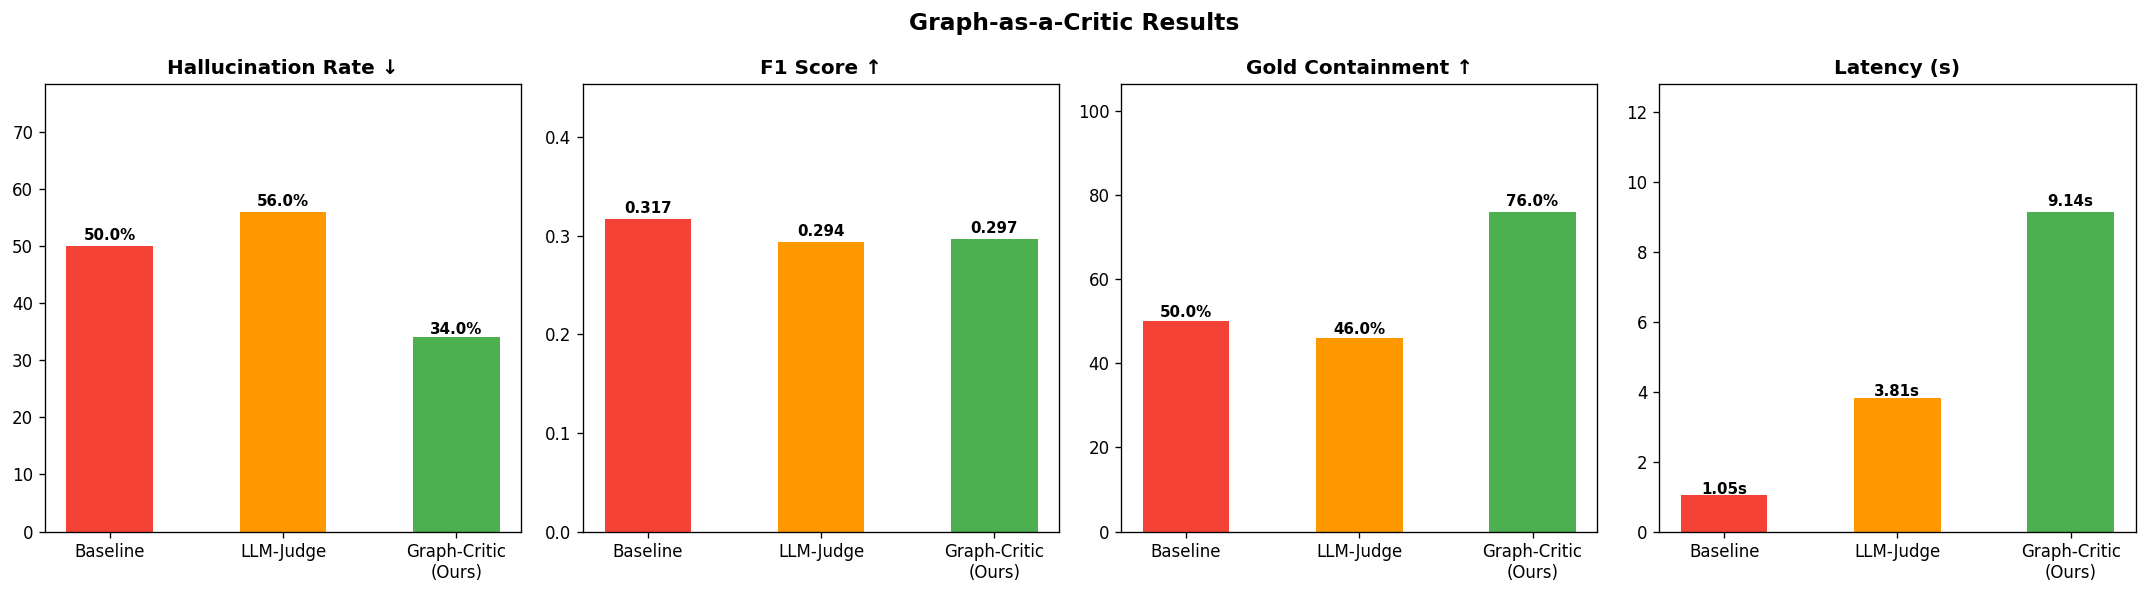

In [10]:
#@title Step 10: Charts

import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120

names = ['Baseline', 'LLM-Judge', 'Graph-Critic\n(Ours)']
cols = ['#F44336', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Graph-as-a-Critic Results', fontsize=14, fontweight='bold')

for ax, vals, title, fmt, suf in [
    (axes[0],[B['halluc_rate'],J['halluc_rate'],G['halluc_rate']],
     'Hallucination Rate ↓','.1f','%'),
    (axes[1],[B['f1'],J['f1'],G['f1']],'F1 Score ↑','.3f',''),
    (axes[2],[B['gold_rate'],J['gold_rate'],G['gold_rate']],
     'Gold Containment ↑','.1f','%'),
    (axes[3],[B['latency'],J['latency'],G['latency']],
     'Latency (s)','.2f','s')]:
    bars = ax.bar(names, vals, color=cols, width=.5)
    ax.set_title(title, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()*1.02,
                f'{v:{fmt}}{suf}', ha='center', fontweight='bold', fontsize=9)
    ax.set_ylim(0, max(vals)*1.4+.01)

plt.tight_layout()
plt.savefig('/content/charts.png', bbox_inches='tight')
plt.show()